In [12]:
import math

def suma_seno(x, tol=1e-8, max_iter=200):
    term = x
    total = x
    n = 0

    for i in range(max_iter):
        n += 1
        #la relacion recursiva
        term = -term * (x**2) / ((2 * n) * (2 * n + 1))
        total = total + term

        # criterio de parada
        if abs(term) < tol * max(1.0, abs(total)):
            break

    return total, i + 1

In [13]:
# Definimos 6 valores en el rango [0, 4π]
valores_x = [0.5, 2.0, math.pi, 2 * math.pi, 3 * math.pi, 4 * math.pi]

print(f"{'x':>8} {'imax':>6} {'suma':>18} {'error relativo':>16}")
for x in valores_x:
    approx, iters = suma_seno(x)
    exacto = math.sin(x)

    # múltiplos de pi donde math.sin(x) es casi 0
    if abs(exacto) < 1e-15:
        error_relativo = abs(approx - exacto) # Error absoluto si el real es ~0
    else:
        error_relativo = abs(approx - exacto) / abs(exacto)

    print(f"{x:8.3f} {iters:6d} {approx:18.10f} {error_relativo:16.2e}")

       x   imax               suma   error relativo
   0.500      4       0.4794255386         2.55e-11
   2.000      8       0.9092974268         4.70e-12
   3.142     10       0.0000000000         1.03e-11
   6.283     15      -0.0000000000         2.44e-11
   9.425     19      -0.0000000003         2.51e-10
  12.566     24       0.0000000001         6.86e-11


Al revisar la tabla del paso anterior, se observa que el error relativo no se mantiene por debajo de la tolerancia de $10^{-8}$ para todos los valores. A medida que $x$ crece (en $3\pi$ y $4\pi$), el error relativo aumenta significativamente. Esto ocurre por la pérdida de significancia. Los términos intermedios de la serie de Taylor crecen mucho antes de empezar a cancelarse entre sí, y la precisión finita de los números flotantes en Python no alcanza para representar esos números enormes y luego restarlos con exactitud.

In [14]:
approx_grande, iters_grande = suma_seno(100.0)
exacto_grande = math.sin(100.0)
print(f"x=100: aproximado={approx_grande}  exacto={exacto_grande}  iteraciones={iters_grande}")

x=100: aproximado=-8.261375671717164e+25  exacto=-0.5063656411097588  iteraciones=111


La suma se dispara a valores absurdos porque los términos de la serie se vuelven gigantescos antes de empezar a decrecer. Es un error de propagación provocado por la incapacidad para manejar la cancelación de números tan grandes

In [15]:
import math

print(f"{'x':>5} | {'Recursiva':>20} | {'Ingenua':>20} | {'Exacto':>20}")
print("-" * 73)

for x in [5.0, 10.0, 15.0, 20.0, 25.0, 30.0]:
    # versión recursiva y el valor exacto
    approx_rec, _ = suma_seno(x)
    exacto = math.sin(x)

    try:
        # versión ingenua
        approx_ing, _ = suma_seno_ingenua(x)
        print(f"{x:5.1f} | {approx_rec:20.10f} | {approx_ing:20.10f} | {exacto:20.10f}")
    except OverflowError:
        # muestra el error si los números se vuelven demasiado grandes
        print(f"{x:5.1f} | {approx_rec:20.10f} | {'ERROR: Overflow':>20} | {exacto:20.10f}")

    x |            Recursiva |              Ingenua |               Exacto
-------------------------------------------------------------------------
  5.0 |        -0.9589242747 |        -0.9589242747 |        -0.9589242747
 10.0 |        -0.5440211107 |        -0.5440211107 |        -0.5440211109
 15.0 |         0.6502878399 |         0.6502878399 |         0.6502878402
 20.0 |         0.9129452556 |         0.9129452478 |         0.9129452507
 25.0 |        -0.1323516973 |        -0.1323514419 |        -0.1323517501
 30.0 |        -0.9880734255 |        -0.9879998573 |        -0.9880316241


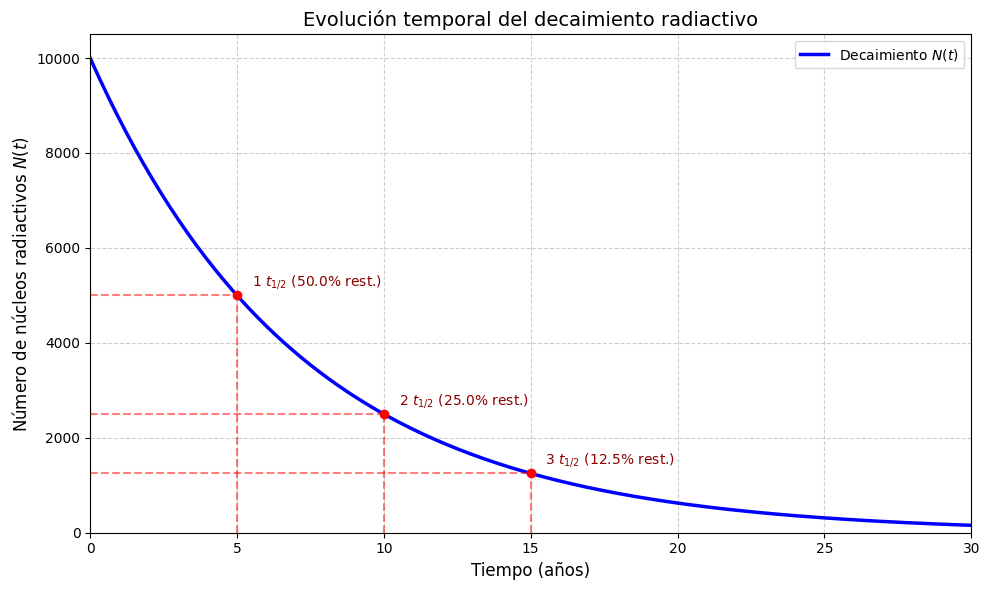

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# constante de decaimiento
N0 = 10000
t_half = 5.0
lam = np.log(2) / t_half

# tiempos entre 0 y 30 años
t = np.linspace(0, 30, 300)

# Cálculo vectorizado de N(t)
N = N0 * np.exp(-lam * t)

# gráfica e identificación de vidas medias
plt.figure(figsize=(10, 6))
plt.plot(t, N, label='Decaimiento $N(t)$', color='blue', linewidth=2.5)

# Marcadores para 1, 2 y 3 vidas medias
vidas_medias = [1, 2, 3]
for vm in vidas_medias:
    t_vm = vm * t_half
    N_vm = N0 * np.exp(-lam * t_vm)

    # Traza puntos y líneas para guiarse
    plt.plot(t_vm, N_vm, 'ro')
    plt.vlines(t_vm, 0, N_vm, linestyles='dashed', colors='red', alpha=0.5)
    plt.hlines(N_vm, 0, t_vm, linestyles='dashed', colors='red', alpha=0.5)

    # muestra la fracción restante
    plt.text(t_vm + 0.5, N_vm + 200, f'{vm} $t_{{1/2}}$ ({N_vm/N0:.1%} rest.)', color='darkred', fontsize=10)


plt.title("Evolución temporal del decaimiento radiactivo", fontsize=14)
plt.xlabel("Tiempo (años)", fontsize=12)
plt.ylabel("Número de núcleos radiactivos $N(t)$", fontsize=12)
plt.xlim(0, 30)
plt.ylim(0, N0 + 500)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
import math
#definicion del decaimiento
def N_decaimiento(t, N0=10000, t_half=5.0):
    lam = math.log(2) / t_half
    return N0 * math.exp(-lam * t)
#estudio de casos
casos_b = [
    (0.0, 1.00),
    (5.0, 0.50),
    (10.0, 0.25),
]

for t, fraccion_esperada in casos_b:
    try:
        obtenido = N_decaimiento(t) / 10000
        ok = abs(obtenido - fraccion_esperada) < 1e-3
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:
        print(f"FAIL  t={t:>5.1f} años   ({e})")

PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250
